Script pour l'entrainement de Resnet (101, 50, 18), deux protocoles, rétinotopique en intégrant une transformation log-polaire lors du ré-entrainement,
cartesien image sans transformation mais l'on applique un masque circulaire sur l'image. 

Tester les 3 data sets :

> full (Imagenet image complète) (done)
> square(le plus petit carré contenant la bounding box) (done)
> focus (meilleur point de fixation après une saccade) (done)


In [1]:
from retinotopy import *

Welcome on Linux-6.5.0-1019-oem-x86_64-with-glibc2.35
CONEC-LID-001
Running on GPU :  NVIDIA RTX A2000 12GB #GPU= 1
On date 2024-04-25, Running learning on host CONEC-LID-001 with device cuda


data_set_type='full'
--------------------------------------------------
args.do_polar=True
Loaded 50001 images under val
Loaded 1281168 images under train


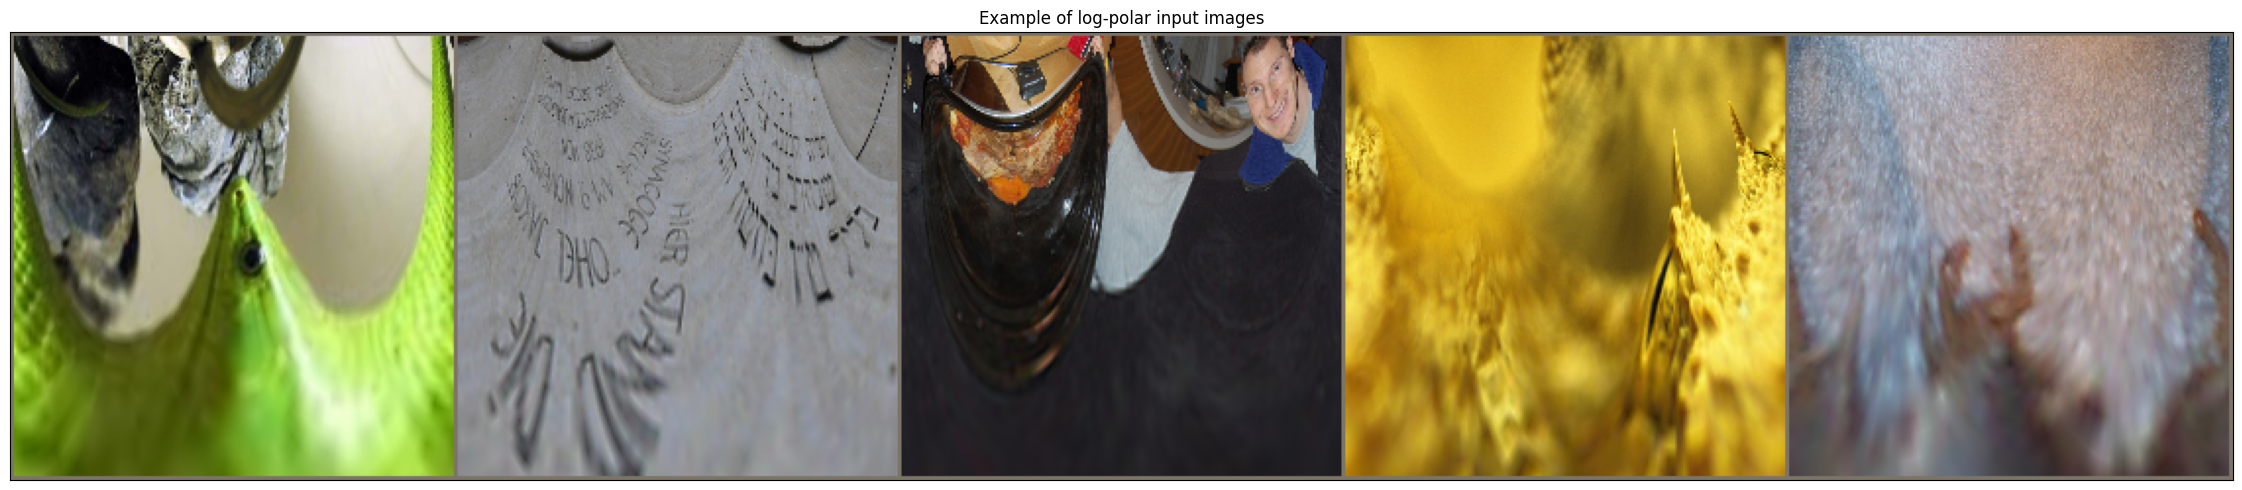

args.do_polar=False
Loaded 50001 images under val
Loaded 1281168 images under train


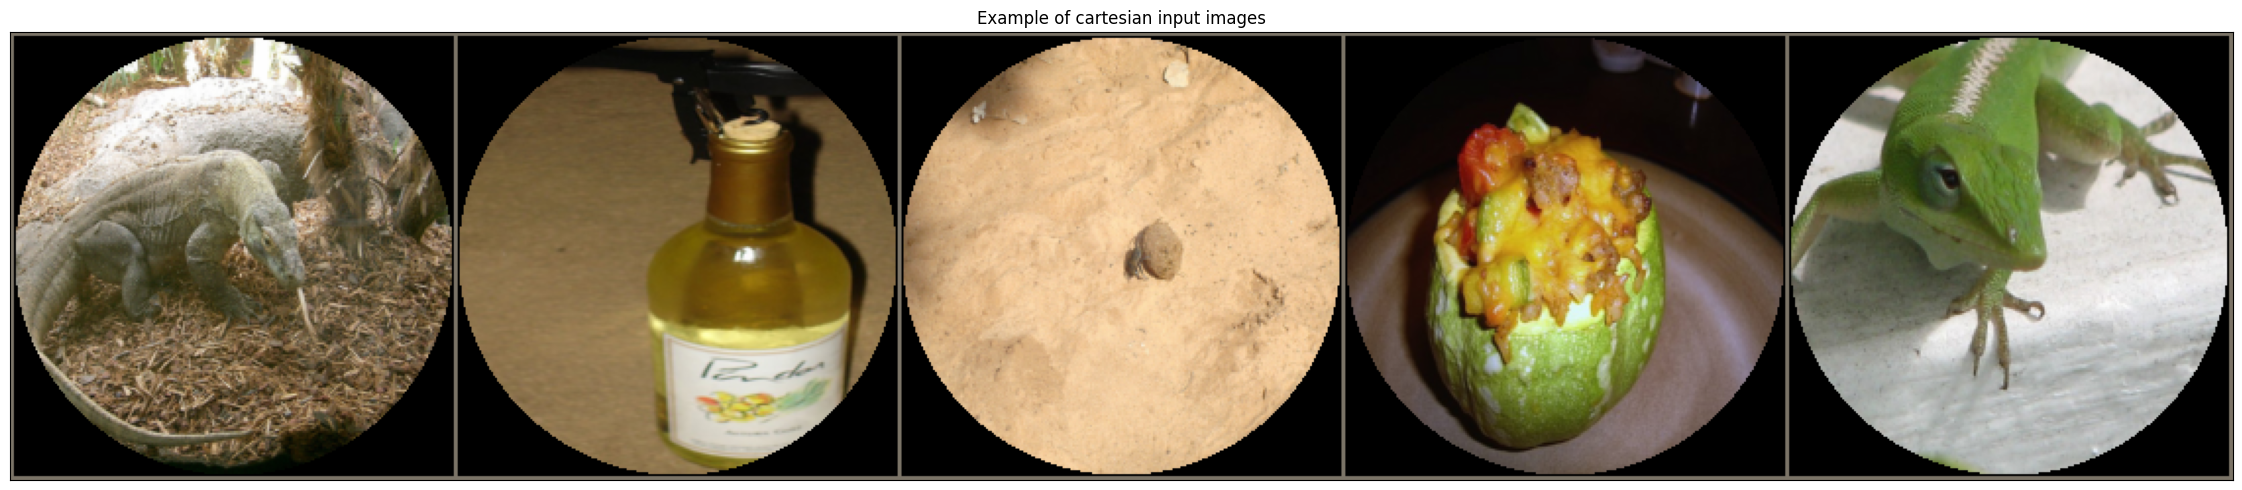

data_set_type='boxes'
--------------------------------------------------
args.do_polar=True
Loaded 50025 images under val
Loaded 544591 images under train


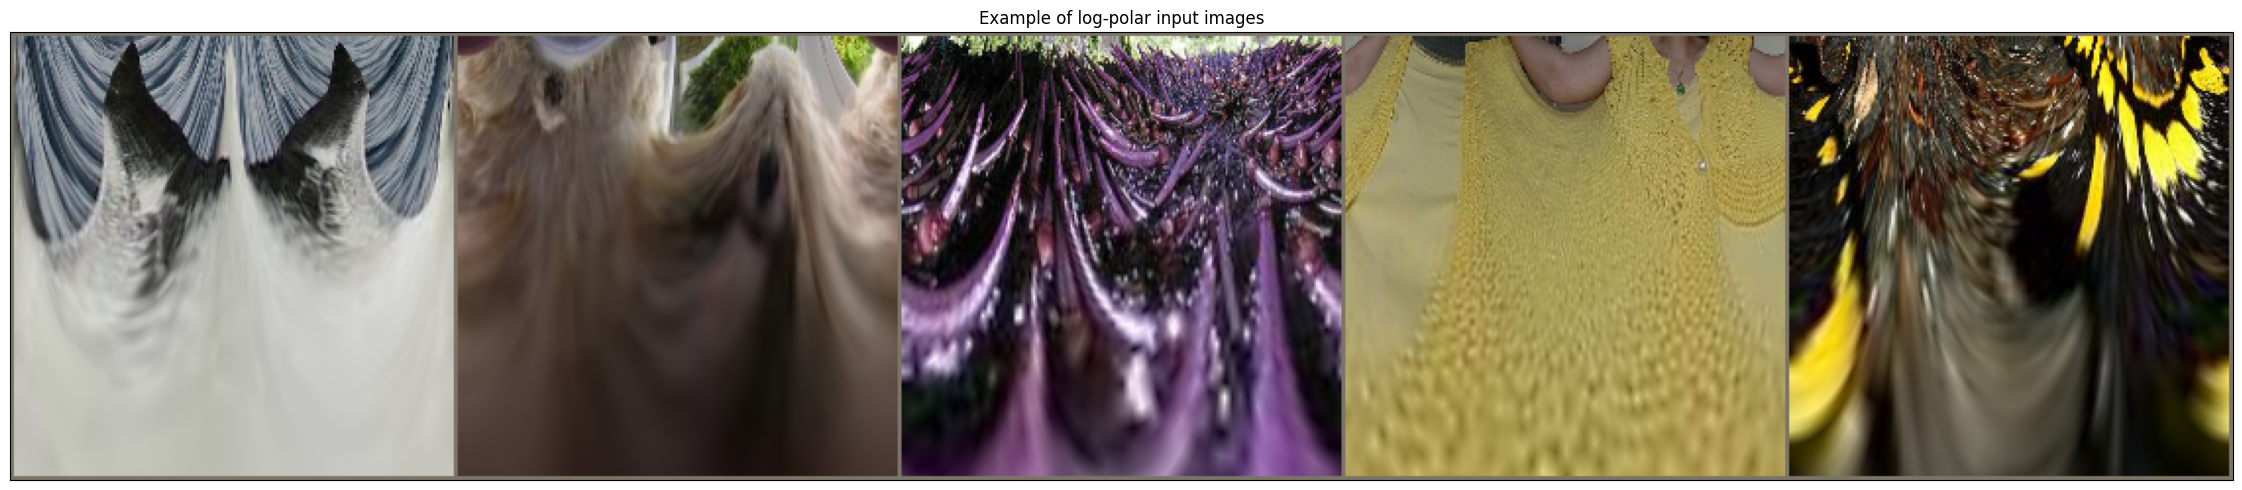

args.do_polar=False
Loaded 50025 images under val
Loaded 544591 images under train


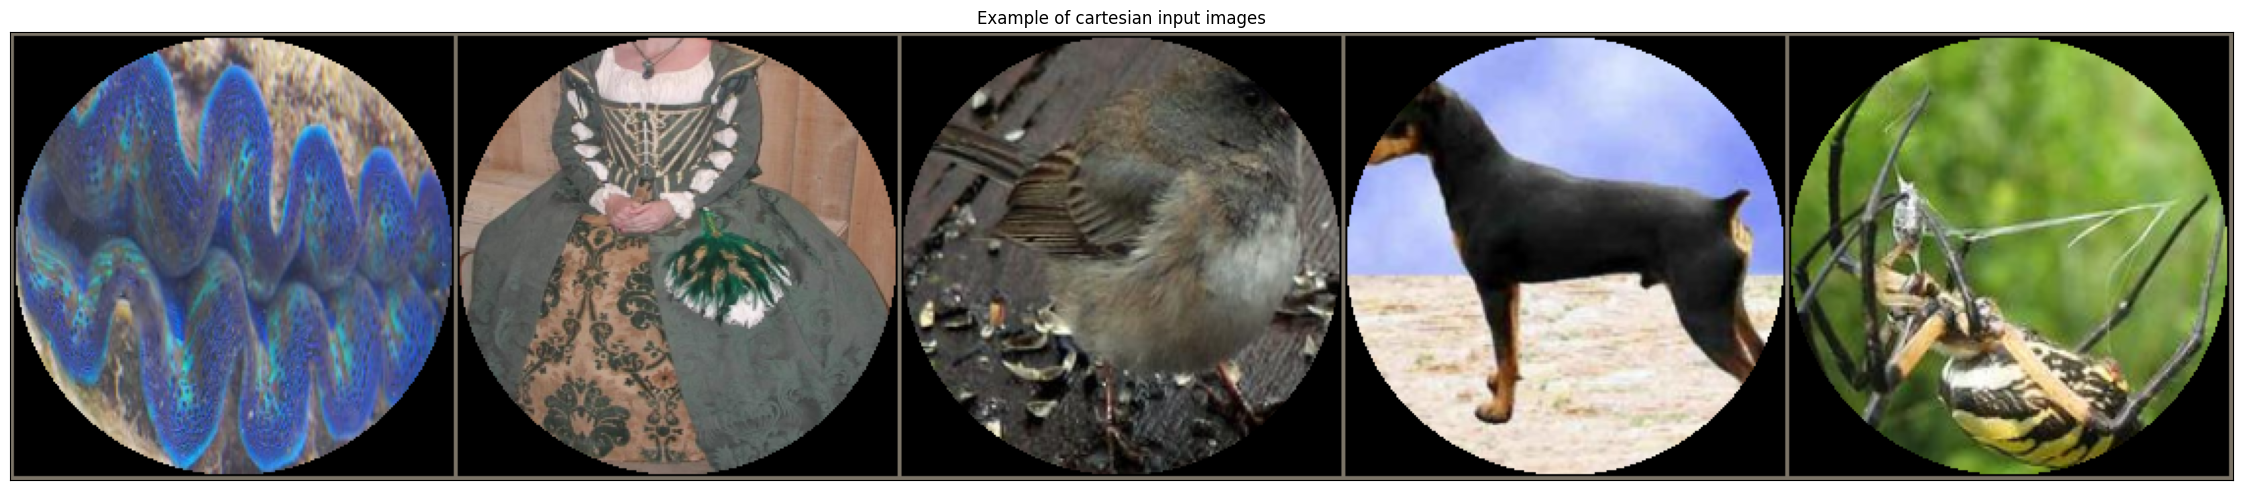

data_set_type='focus'
--------------------------------------------------
args.do_polar=True
Loaded 49981 images under val
Loaded 498828 images under train


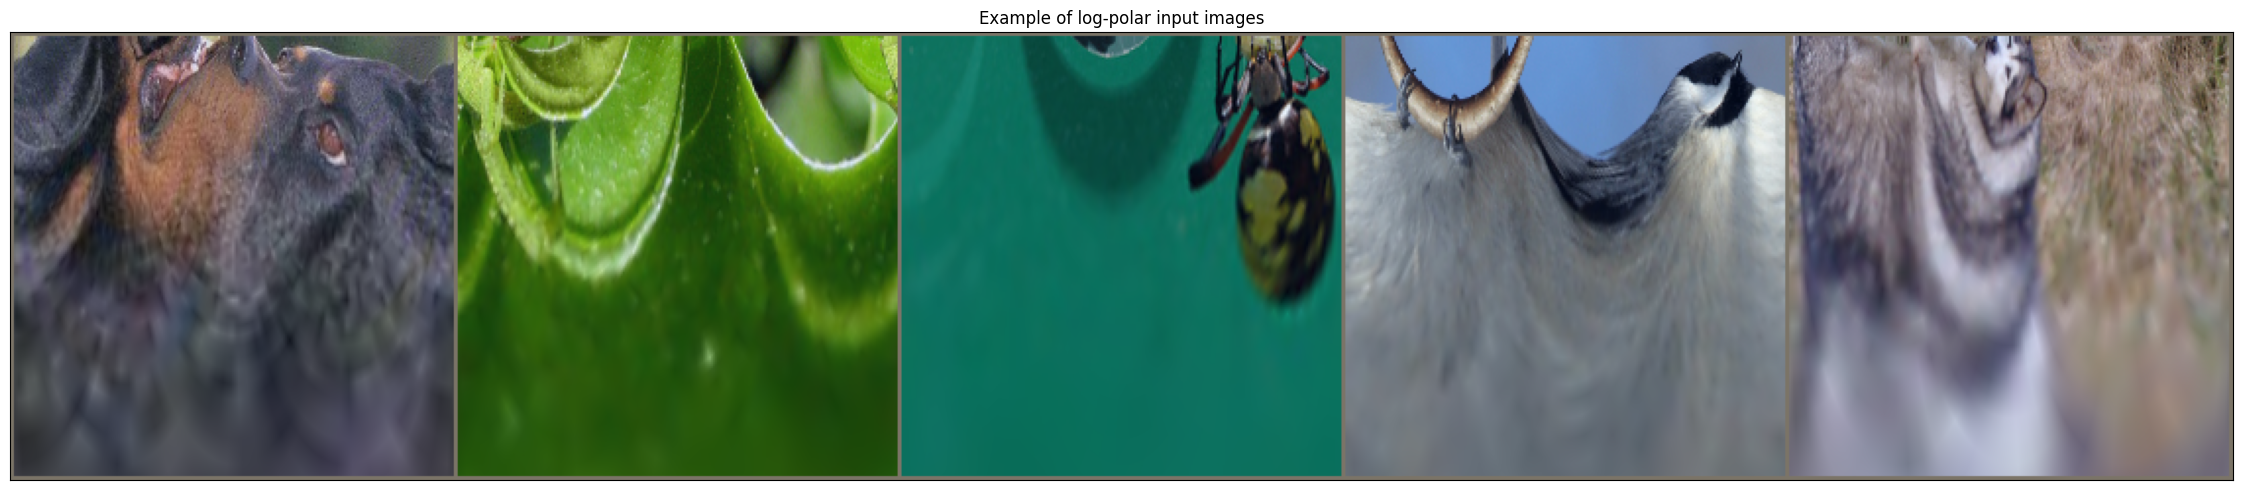

args.do_polar=False
Loaded 49981 images under val
Loaded 498828 images under train


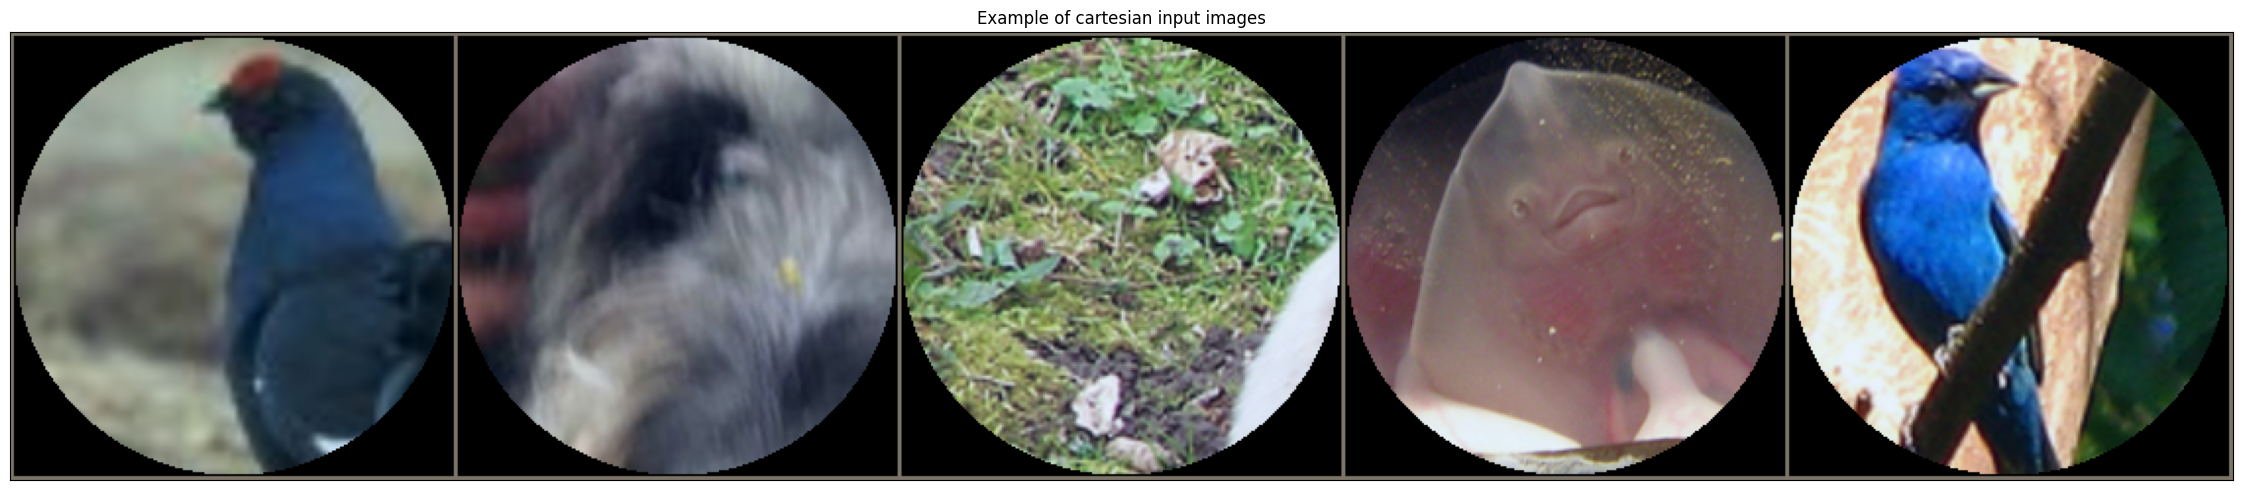

In [2]:
data_set_types = ['full', 'boxes', 'focus', ]

for data_set_type in data_set_types:
    print(50*'=')
    print(f'{data_set_type=}')
    args = Params()
    args.root  = f'{DATAROOT}/Imagenet_{data_set_type}' # Directory containing images to perform the training
    print(50*'-')

    for args.do_polar in [True, False]:
        print(f'{args.do_polar=}')
        dataloaders = datasets_transforms(args)
        for i_step, (images, labels) in enumerate(dataloaders['train']):
            images, labels = images.to('cpu'), labels.to('cpu')
            break
        imshow(images[:5], title='Example of cartesian input images' if not(args.do_polar) else 'Example of log-polar input images', fig_height=5)
        plt.show()
    print(50*'=')

# Training function

In [3]:
def train_model(args, model, dataloaders, each_steps=64, verbose=True):
    # if torch.cuda.is_available():
    #     model = model.to(device, memory_format=torch.channels_last)
    #     torch.cuda.amp.GradScaler(enabled=True)
    # else:
    #     model = model.to(device)
    model = model.to(device)
    # retraining the full model
    for param in model.parameters():
        param.requires_grad = True        

    if args.beta2 > 0.: 
        optimizer = torch.optim.Adam(model.parameters(), lr=args.lr, betas=(1-args.momentum, 1-args.beta2)) 
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=args.lr, momentum=1-args.momentum) # to set training variables

    df_train = pd.DataFrame([], columns=['epoch', 'i_image', 'total_image', 'avg_loss', 'avg_acc', 'avg_loss_val', 'avg_acc_val', 'time']) 

    criterion = nn.CrossEntropyLoss() #binary_cross_entropy_with_logits
    total_image = 0
    since = time.time()

    n_train = len(dataloaders['train'].dataset)
    n_train_stop = args.n_train_stop
    if n_train_stop==0: n_train_stop = n_train

    for i_epoch in range(args.num_epochs):
        i_image = 0
        for i_step, (images, labels) in enumerate(dataloaders['train']):
            images, labels = images.to(device), labels.to(device)
            total_image += len(images)
            i_image += len(images)
            if i_image > n_train_stop: break

            optimizer.zero_grad()

            outputs = model(images)
             
            loss = criterion(outputs, labels)            
            loss.backward()
            optimizer.step()

            _, preds = torch.max(outputs.data, dim=1)

            avg_loss = loss.item() * images.size(0)
            avg_acc = torch.mean((preds == labels.data)*1.).cpu().item()

            if (i_step % (max(n_train_stop//args.batch_size//each_steps, 1))==0) or (i_step == n_train_stop-1):
                with torch.no_grad():
                    loss_val = 0
                    acc_val = 0
                    model = model.eval()
                    n_val = len(dataloaders['val'])
                    for _, (images, labels) in enumerate(dataloaders['val']):
                        images, labels = images.to(device), labels.to(device)

                        outputs = model(images)

                        loss = criterion(outputs, labels)

                        loss_val += loss.item() * images.size(0)

                        _, preds = torch.max(outputs.data, dim=1)
                        acc_val += torch.mean((preds == labels.data)*1.).cpu().item()

                    avg_loss_val = loss_val / n_val
                    avg_acc_val = acc_val / n_val

                    df_train.loc[len(df_train)] = {'epoch': i_epoch, 'i_image':i_image, 'total_image':total_image, 'avg_loss':avg_loss, 'avg_acc':avg_acc, 'avg_loss_val':avg_loss_val, 'avg_acc_val':avg_acc_val, 'time':time.time() - since}
                    if verbose:  print(f"Epoch {i_epoch}, i_image {i_image} : train= loss: {avg_loss:.4f} / acc : {avg_acc:.4f} - val= loss : {avg_loss_val:.4f} / acc : {avg_acc_val:.4f} / time:{time.time() - since:.1f}")

    if torch.cuda.is_available(): torch.cuda.empty_cache()        
    return model, df_train

# Training function

In [4]:
# Training and saving the networks
for data_set_type in data_set_types:


    print(50*'=')
    print(f'{data_set_type=}')
    args = Params()
    args.root  = f'{DATAROOT}/Imagenet_{data_set_type}' # Directory containing images to perform the training
    print(50*'-')

    fig, ax = plt.subplots(1, 1, figsize=(fig_width, fig_width/phi), subplotpars=subplotpars)
        
    for model_name, lw in  zip(['resnet101', 'resnet50', 'resnet18'], [4, 2, 1]): #, 
        for do_polar, color in zip([True, False], ['b', 'r']):
            print(50*'.')

            filename = f'{data_cache}/{datetag}_{data_set_type}_{model_name}_{do_polar=}'
            json_filename = filename + '.json'
            model_filename = filename + '.pt'


            if os.path.isfile(model_filename):
                print(f"Load pre-trained resnet {model_filename}")
                df_train = pd.read_json(json_filename, orient='index')
                print(f"{model_filename}: accuracy = {df_train['avg_acc_val'][-5:].mean():.3f}")

            elif os.path.isfile(model_filename + '.lock'):
                # we want to have a file but it's locked
                print(f'Path {model_filename} is locked')
                # model_retrain[model_name].load_state_dict(torch.load(model_filename, map_location=torch.device(device)))
                df_train = None
            elif not os.path.isfile(model_filename + '.lock'):
                print(f"Training resnet {model_filename}")
                
                # either we do not need a file or it does not exist (or it's locked)
                touch(model_filename + '.lock') # we want to have a file let's lock it
            
                args.do_polar = do_polar

                # get the weights of the network
                dataloaders = datasets_transforms(args)
                # get the architecture of the network
                # model_retrain = torch.hub.load('pytorch/vision:v0.10.0', model_name, pretrained=True)            
                if model_name == 'resnet50':
                    model_retrain = torchvision.models.resnet50(weights=torchvision.models.ResNet50_Weights.DEFAULT)
                elif model_name == 'resnet18':
                    model_retrain = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
                else:
                    model_retrain = torchvision.models.resnet101(weights=torchvision.models.ResNet101_Weights.DEFAULT)
                                    
                if args.do_polar: 
                    model_retrain = make_padding_circular_again(model_retrain)


                print("Re-training pretrained model...", model_filename)
                print(f"Traning {model_name}, image_size={args.image_size}")
                since = time.time()

                model_retrain, df_train = train_model(args, model_retrain, dataloaders=dataloaders)
                
                elapsed_time = time.time() - since
                print(f"Training completed in {elapsed_time // 60:.0f}m {elapsed_time % 60:.0f}s")
                print(f"Saving...{model_filename}")
                torch.save(model_retrain.state_dict(), model_filename)
                df_train.to_json(json_filename, orient='index', indent=2)
                if device=='cuda': torch.cuda.empty_cache()

                print()     
                
            if not(df_train is None):
                import lmfit
                from lmfit import Parameters, Model


                x = df_train['total_image'].values
                y = df_train['avg_acc_val'].values

                # Define the function
                def model(x, acc_max, acc_min, x_50) :
                    return acc_max - (acc_max-acc_min) * np.exp( - x / x_50)

                # Init the sigmoid model as an lmfit Model object 
                mod = Model(model)
                pars = Parameters()
                # Add the initial parameters guesses
                pars.add_many(('acc_max', np.max(y), True,  0.0, 1.),
                            ('x_50', np.max(x)/20, True, 1, np.max(x)),
                            ('acc_min', 1/1000, True,  0.0, 1.))
                # And fit using least-square minimization
                out = mod.fit(y, pars, x=x, nan_policy='omit', max_nfev = 3000)
                # Print the result
                result = f"fitted max accuracy= {out.best_values['acc_max']:.2f}, speed= {out.best_values['x_50']:.1f}"
                print(result)

                df_train_roll = df_train.rolling(window=5, min_periods=1, center=False).mean()
                ax = df_train_roll.plot(x='total_image', y='avg_acc', 
                                    c=color, ls='dashed', lw=lw,
                                    grid=True, ax=ax, label='TRAIN: ' + json_filename.strip(data_cache + '/').strip('.json'))    
                ax = df_train_roll.plot(x='total_image', y='avg_acc_val', 
                                    c=color, lw=lw,
                                    grid=True, ax=ax, label='VAL: ' + json_filename.strip(data_cache + '/').strip('.json') + '-' + result)    
                if os.path.isfile(model_filename + '.lock'): os.remove(model_filename + '.lock')

    ax.set_ylim(.15, .85)            
    ax.set_ylim(.05, .95)            
    ax.set_yscale('logit')

    print(50*'=')

data_set_type='full'
Path cached_data/2024-04-25_full_resnet101_do_polar=True.pt is locked
Path cached_data/2024-04-25_full_resnet101_do_polar=False.pt is locked
Training resnet cached_data/2024-04-25_full_resnet50_do_polar=True.pt
Loaded 50001 images under val
Loaded 1281168 images under train
Re-training pretrained model... cached_data/2024-04-25_full_resnet50_do_polar=True.pt
Traning resnet50, image_size=224


: 